In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].astype(str).str.strip()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0, '1': 1, '0': 0}).astype(int)

print("Churn rate:", df['Churn'].mean().round(3))
print("Missing values:", df.isnull().sum().sum())

Churn rate: 0.265
Missing values: 0


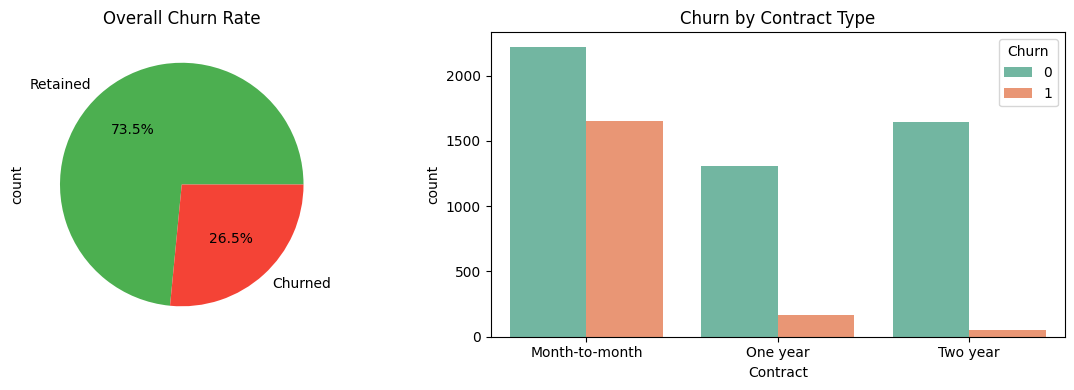

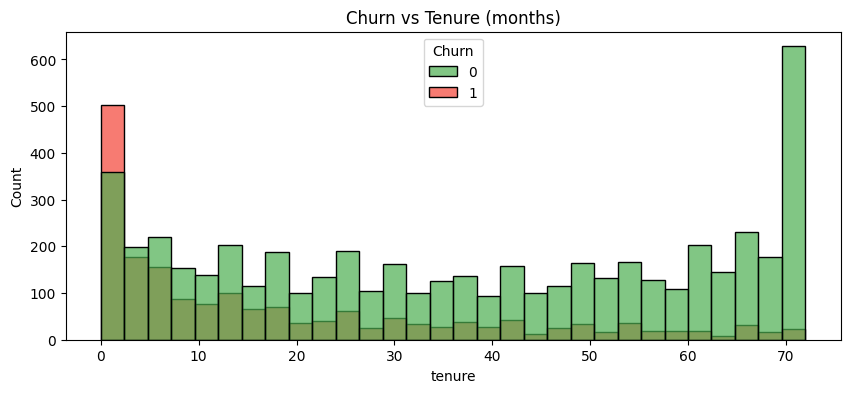

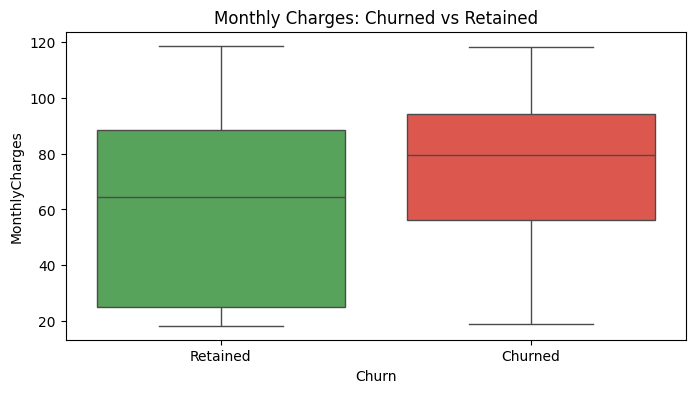

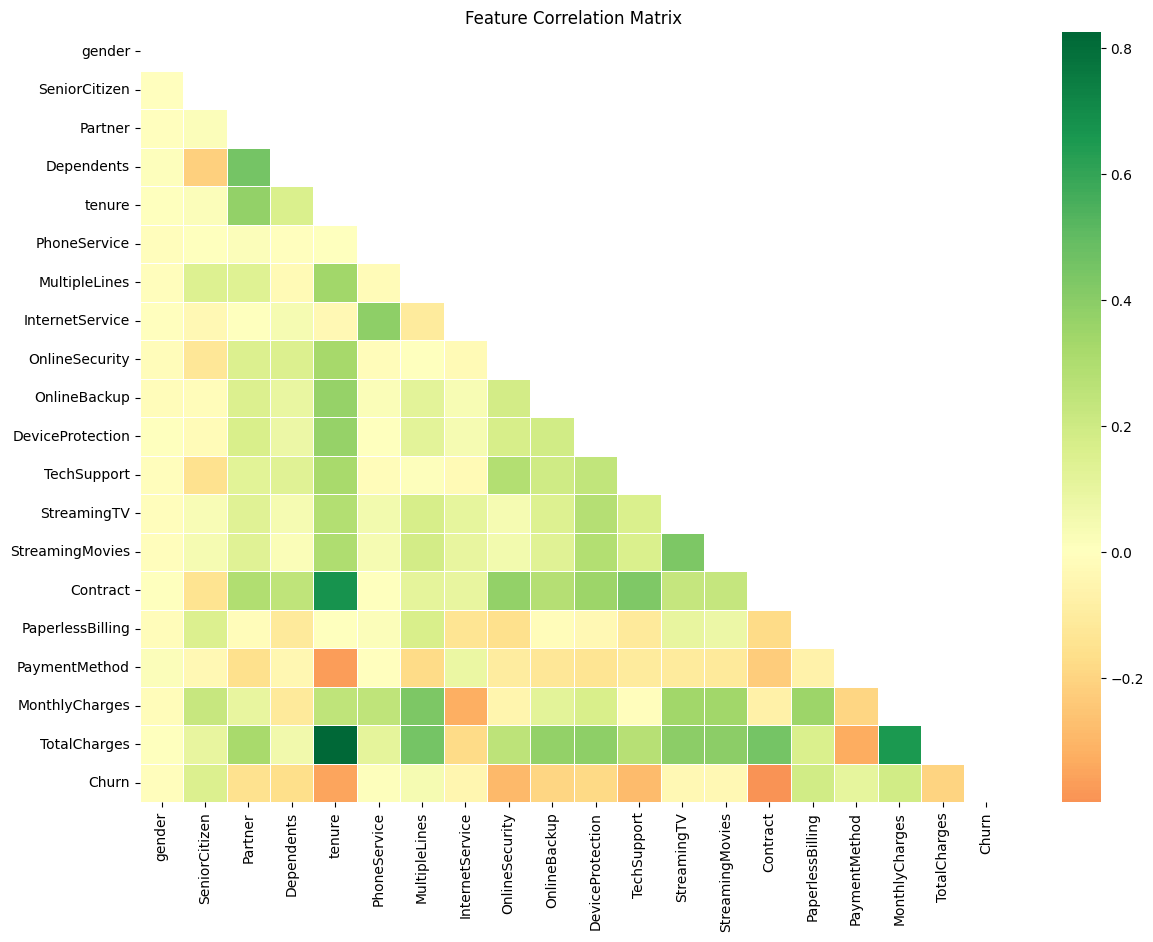

In [15]:
# ── Plot 1: Churn distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0],
    colors=['#4CAF50','#F44336'], labels=['Retained','Churned'])
axes[0].set_title('Overall Churn Rate')

# ── Plot 2: Churn by Contract Type ──
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title('Churn by Contract Type')
plt.tight_layout()
plt.savefig('plot1_churn_overview.png', dpi=150)
plt.show()

# ── Plot 3: Churn by Tenure ──
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={0:'#4CAF50', 1:'#F44336'}, alpha=0.7)
plt.title('Churn vs Tenure (months)')
plt.savefig('plot2_tenure.png', dpi=150)
plt.show()

# ── Plot 4: Monthly charges vs Churn ──
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    palette=['#4CAF50', '#F44336']   # ← CHANGE HERE
)
plt.title('Monthly Charges: Churned vs Retained')
plt.xticks([0,1], ['Retained','Churned'])
plt.savefig('plot3_charges.png', dpi=150)
plt.show()

# ── Plot 5: Correlation heatmap ──
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes('object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.savefig('plot4_correlation.png', dpi=150)
plt.show()

              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      1035
     Churned       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8458


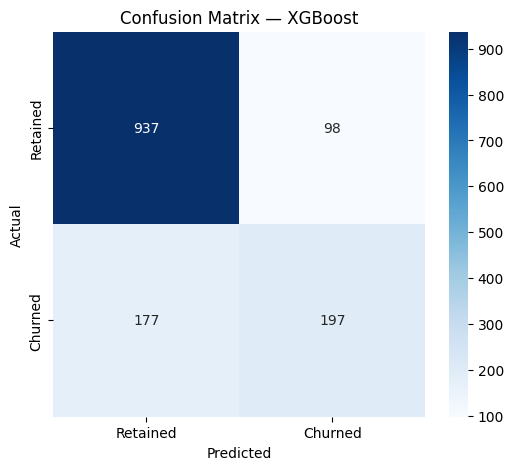

In [16]:
#  Prepare features
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#  Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

#  Evaluate
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob).round(4))

#  Plot 6: Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('plot5_confusion_matrix.png', dpi=150)
plt.show()

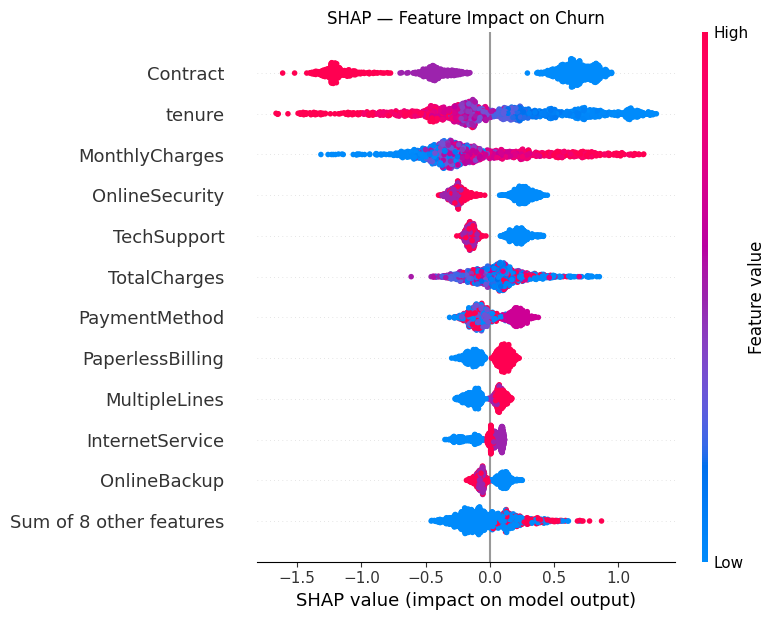

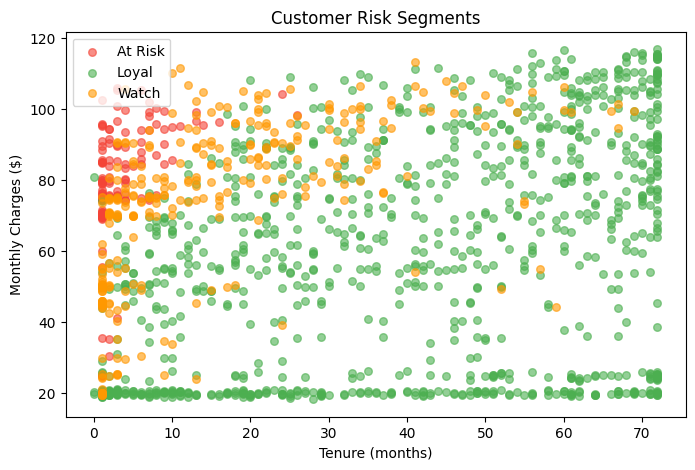

Saved churn_predictions.csv


In [17]:
# Plot 7: SHAP beeswarm (explains WHY)
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

plt.figure()
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title('SHAP — Feature Impact on Churn')
plt.tight_layout()
plt.savefig('plot6_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 8: Customer Risk Segmentation
df_test = X_test.copy()
df_test['ChurnProb'] = y_prob
df_test['Actual'] = y_test.values

def segment(p):
    if p >= 0.7: return 'At Risk'
    elif p >= 0.4: return 'Watch'
    else: return 'Loyal'

df_test['Segment'] = df_test['ChurnProb'].apply(segment)

plt.figure(figsize=(8, 5))
colors = {'At Risk': '#F44336', 'Watch': '#FF9800', 'Loyal': '#4CAF50'}
for seg, grp in df_test.groupby('Segment'):
    plt.scatter(grp['tenure'], grp['MonthlyCharges'],
                label=seg, alpha=0.6, color=colors[seg], s=30)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Risk Segments')
plt.legend()
plt.savefig('plot7_segments.png', dpi=150)
plt.show()

#  Export predictions CSV
df_test.to_csv('churn_predictions.csv', index=False)
print("Saved churn_predictions.csv")

In [18]:
import pickle

# Save the trained model
with open('xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save the feature columns
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("Saved! Feature columns:", list(X_train.columns))

# Download both files
from google.colab import files
files.download('xgb_churn_model.pkl')
files.download('feature_columns.pkl')

Saved! Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>